In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('dados/banking.db')

financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'CONTA', 'NOME_CONTA', 'saldo_medio']

query = f"""
SELECT 
    {', '.join(financial_indicators)} 
FROM 
    balancetes_media_ano
WHERE 
    cnpj IN (
        SELECT cnpj
        FROM balancetes_media_ano
        GROUP BY ano, cnpj
    );"""

df = pd.read_sql_query(query, conn)

conn.close()

df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

df['nome_conta'] = (df['nome_conta']
                      .str.lower()
                      .str.normalize('NFD')
                      .str.replace(r'[\u0300-\u036f]', '', regex=True))



"\ndf = df.pivot(\n    index=['ano', 'cnpj', 'nome'],\n    columns='nome_conta',\n    values='saldo'\n).reset_index()\n\n# Valor mínimo da conta operações de crédito\ndf = df[df[16000001] > 1000000]\ndf.dropna(subset=[39999993], inplace=True)\n\n"

In [379]:
# 1. Agrupar e contar valores únicos
inconsistencias = df.groupby('conta')['nome_conta'].nunique()

# 2. Filtrar apenas onde a contagem é > 1
contas_duplicadas = inconsistencias[inconsistencias > 1].index

# 3. Visualizar os dados problemáticos
df_problema = df[df['conta'].isin(contas_duplicadas)].sort_values(by='conta')

print(f"Total de contas com nomes divergentes: {len(contas_duplicadas)}")

Total de contas com nomes divergentes: 39


In [380]:
# Padronizando nomes
df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"



In [381]:
# 1. Agrupar e contar valores únicos
inconsistencias = df.groupby('nome_conta')['conta'].nunique()

# 2. Filtrar apenas onde a contagem é > 1
contas_duplicadas = inconsistencias[inconsistencias > 1].index

# 3. Visualizar os dados problemáticos
df_problema = df[df['nome_conta'].isin(contas_duplicadas)].sort_values(by='nome_conta')

print(f"Total de contas com nomes divergentes: {len(contas_duplicadas)}")

# 1. Primeiro, pegamos apenas os pares únicos de conta/nome para limpar repetições exatas
pares_unicos = df[['conta', 'nome_conta']].drop_duplicates()

# 2. Agora, verificamos quais 'conta' ainda aparecem duplicadas (indicando nomes diferentes)
mascara_inconsistencia = pares_unicos.duplicated(subset=['nome_conta'], keep=False)

# 3. Filtramos e mostramos o resultado
tabela_inconsistencias = pares_unicos[mascara_inconsistencia].sort_values(by='nome_conta')


Total de contas com nomes divergentes: 21


In [382]:
# Conta duplicada
df = df[df['conta'] != 88000008]
df = df[df['conta'] != 47100004]
df = df[df['conta'] != 51100007]
df = df[df['conta'] != 78100004]
df = df[df['conta'] != 61000001]



In [384]:

df = df.pivot(
    index=['ano', 'cnpj', 'nome'],
    columns='conta',
    values='saldo'
).reset_index()

# Valor mínimo da conta operações de crédito
df = df[df[16000001] > 1000000]
df.dropna(subset=[39999993], inplace=True)


In [ ]:
# Dividindo os valores pelo Ativo Total (39999993)
colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 39999993]]
for col in colunas_a_dividir:
    df[col] = df[col] / df[39999993]
df.drop(columns=[39999993, 99999995], inplace=True)
df_filtrado = df


In [ ]:
mapa_contas = (
    df.groupby('conta')['nome_conta']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

novo_mapeamento = {}

for conta, nome in mapa_contas.items():
    conta_str = str(conta) # Garante que podemos verificar o início
    
    if conta_str.startswith('1'):
        novo_nome = f"ativo realizavel - {nome}"
    elif conta_str.startswith('2'):
        novo_nome = f"ativo permanente - {nome}"
    elif conta_str.startswith('3'):
        novo_nome = f"compensacao ativa - {nome}"
    elif conta_str.startswith('4'):
        novo_nome = f"passivo exigivel - {nome}"
    elif conta_str.startswith('6'):
        novo_nome = f"patrimonio liquido - {nome}"
    elif conta_str.startswith('7'):
        novo_nome = f"resultado credor - {nome}"
    elif conta_str.startswith('8'):
        novo_nome = f"resultado devedor - {nome}"
    elif conta_str.startswith('9'):
        novo_nome = f"compensacao passiva - {nome}"
    else:
        novo_nome = nome # Mantém o original se não houver regra
        
    novo_mapeamento[conta] = novo_nome

mapa_contas = novo_mapeamento

df = df.rename(columns=novo_mapeamento)


In [386]:
# Eliminando colunas esparsas

# 1. Calcular a porcentagem de zeros em cada coluna
esparsidade = df.isnull().sum() / len(df)

# 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
print(f"Colunas com > 50% de zeros: {sum(esparsidade > 0.50)}")
print(f"Colunas com > 90% de zeros: {sum(esparsidade > 0.90)}")
print(f"Colunas com > 95% de zeros: {sum(esparsidade > 0.95)}")

# 3. Definir o limiar (Recomendação: 0.90 a 0.95)
limiar_corte = 0.95

# Identificar colunas a serem removidas
colunas_para_remover = esparsidade[esparsidade > limiar_corte].index

# 4. Criar o novo dataset filtrado
df_filtrado = df.drop(columns=colunas_para_remover)

print(f"\nDimensão original: {df.shape[1]} colunas")
print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
df_filtrado.fillna(0, inplace=True)

Colunas com > 50% de zeros: 129
Colunas com > 90% de zeros: 80
Colunas com > 95% de zeros: 61

Dimensão original: 208 colunas
Dimensão após corte de esparsidade: 147 colunas


<Axes: xlabel='conta', ylabel='conta'>

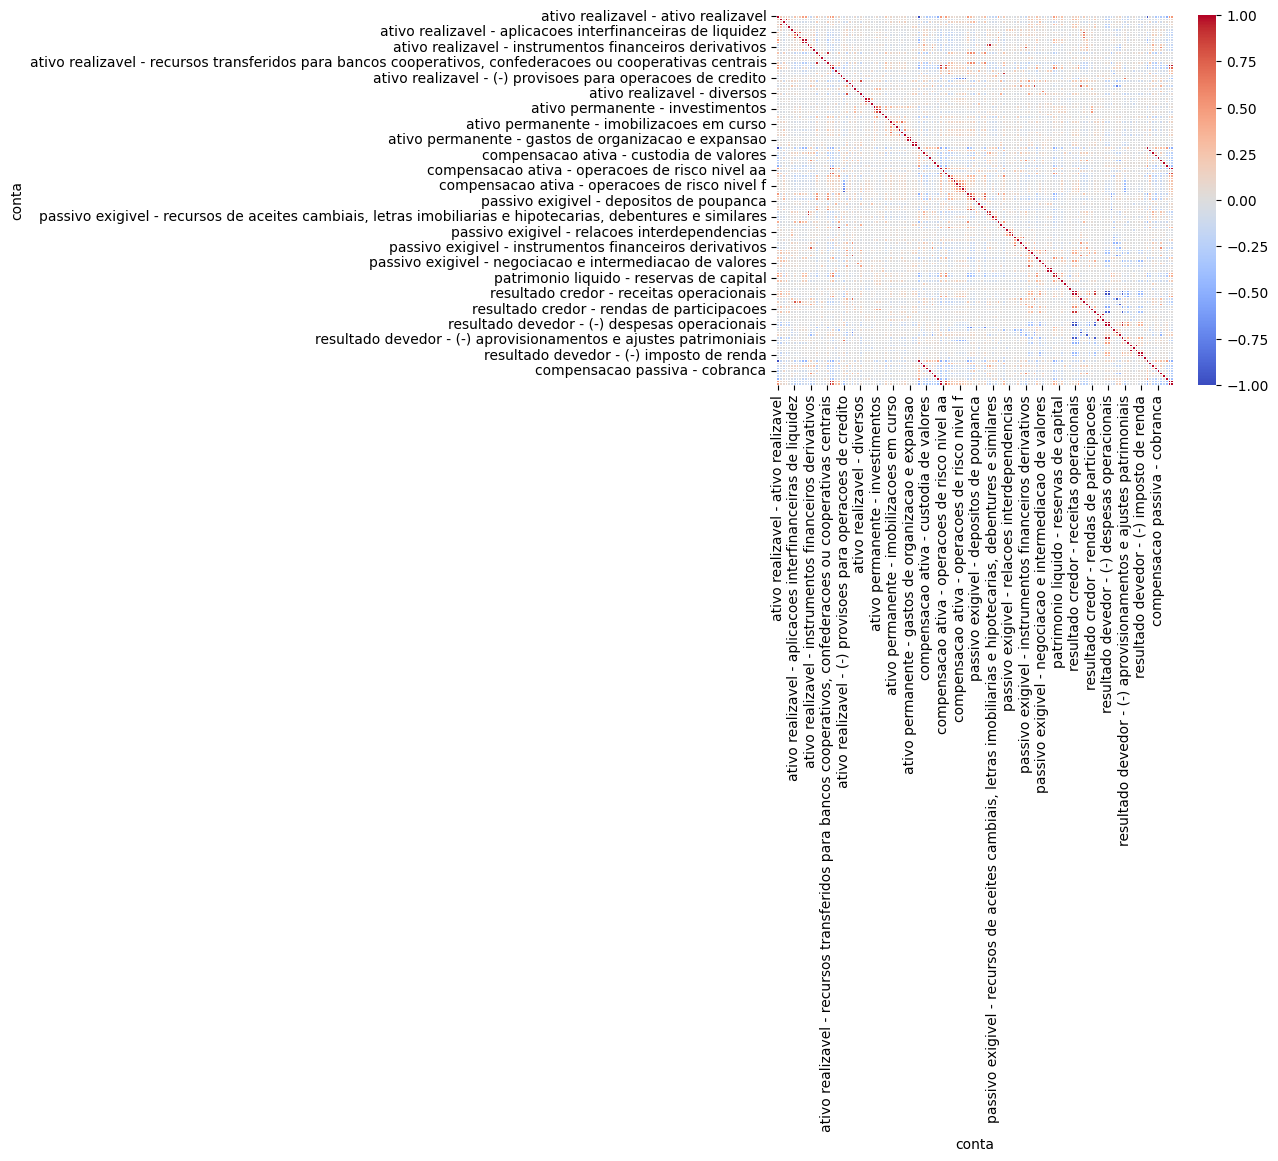

In [387]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit the scaler to the data and transform the data
# X_scaled will be a NumPy array, not a DataFrame
X = df_filtrado.drop(columns=['ano', 'cnpj', 'nome'], axis=1)
# X.dropna(axis=1, inplace=True)
X.fillna(0, inplace=True)

corr_matrix = X.corr(method='pearson')

# Usar um heatmap do seaborn
# Cmap='coolwarm' é ótimo, pois destaca cores diferentes para correlação positiva e negativa
sns.heatmap(
    corr_matrix, 
    annot=False,            # Não mostrar os números (seria ilegível com 159)
    cmap='coolwarm', 
    fmt=".2f",              # Formato de duas casas decimais
    linewidths=.5,          # Linhas entre as células
    vmin=-1, vmax=1         # Definir escala de -1 a 1
)


In [388]:
# 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
corr_matrix_abs = corr_matrix.abs()

# 2. Selecionar apenas o triângulo superior da matriz
# Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 3. Definir o Limiar de Corte (Threshold)
# 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
threshold = 0.90

# Encontrar colunas que têm correlação > threshold com qualquer outra coluna
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
print(to_drop)

# Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
X.drop(columns=to_drop, inplace=True)
X.columns = X.columns.astype(str)
X_scaled = scaler.fit_transform(X)

# Optional: Convert back to a DataFrame for easier handling, using the original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)




--- Contas Redundantes a Descartar (Correlação > 0.9) ---
Número de variáveis sugeridas para remoção: 35
['ativo realizavel - depositos bancarios', 'ativo realizavel - livres', 'ativo realizavel - recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais', 'ativo realizavel - outros valores e bens', 'ativo realizavel - outros valores e bens', 'ativo permanente - gastos de organizacao e expansao', 'ativo permanente - ativos intangiveis', 'compensacao ativa - compensacao ativa', 'compensacao ativa - classificacao da carteira de creditos', 'compensacao ativa - operacoes de risco nivel h', 'passivo exigivel - depositos a prazo', 'passivo exigivel - carteira propria', 'passivo exigivel - repasses interfinanceiros', 'receitas de exercicios futuros', 'patrimonio liquido - capital social', 'resultado credor - receitas operacionais', 'resultado credor - outras receitas operacionais', 'resultado credor - outras receitas nao operacionais', 'resultado devedor - (-) re

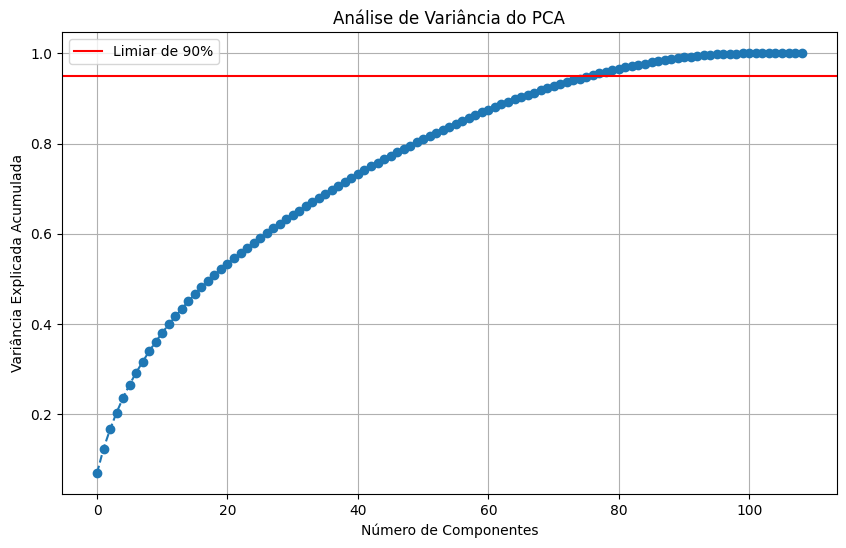

Número ideal de componentes para reter 95% da informação: 77


In [389]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 2. Ajustar o PCA sem limitar componentes (para análise)
pca_analise = PCA()
pca_analise.fit(X_scaled)

# Calcular a variância acumulada
variancia_acumulada = np.cumsum(pca_analise.explained_variance_ratio_)

# Plotar o gráfico para decisão visual
plt.figure(figsize=(10, 6))
plt.plot(variancia_acumulada, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Análise de Variância do PCA')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='Limiar de 90%') # Linha de corte
plt.legend()
plt.show()

# Calcular matematicamente o número ideal (k) para 90% de variância
k_ideal = np.argmax(variancia_acumulada >= 0.95) + 1
print(f"Número ideal de componentes para reter 95% da informação: {k_ideal}")

In [390]:
# 3. Aplicar o PCA com o número de componentes escolhido
pca_final = PCA(n_components=k_ideal)
X_pca = pca_final.fit_transform(X_scaled)

features = X.columns.tolist()

# Criar um DataFrame com os pesos (Loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(k_ideal)], 
    index=features
)

#loadings.to_csv('loadings.csv', index=False)
# Para cada Componente Principal, ver as 5 variáveis mais influentes
for i in range(3): # Vamos olhar só os 3 primeiros componentes como exemplo
    coluna = f'PC{i+1}'
    print(f"\n--- Principais influenciadores do {coluna} ---")
    # Ordenar pelo valor absoluto do peso
    top_features = loadings[coluna].abs().sort_values(ascending=False).head(5)
    
    # Mostrar a feature e se a correlação é positiva ou negativa
    for feature, peso in top_features.items():
        sinal = "+" if loadings.loc[feature, coluna] > 0 else "-"
        print(f"{feature}: {sinal} ({loadings.loc[feature, coluna]:.4f})")


--- Principais influenciadores do PC1 ---
ativo realizavel - operacoes de credito: + (0.2395)
compensacao ativa - negociacao e intermediacao de valores: - (-0.2091)
ativo realizavel - carteira de cambio: - (-0.1831)
ativo realizavel - emprestimos e direitos creditorios descontados: + (0.1816)
compensacao ativa - operacoes de risco nivel b: + (0.1793)

--- Principais influenciadores do PC2 ---
passivo exigivel - outras obrigacoes: + (0.2708)
patrimonio liquido - patrimonio liquido: + (0.2670)
resultado credor - rendas de operacoes de credito: + (0.2195)
compensacao ativa - operacoes de risco nivel a: + (0.2079)
resultado credor - resultado credor: + (0.2056)

--- Principais influenciadores do PC3 ---
passivo exigivel - passivo exigivel: + (0.2910)
patrimonio liquido - patrimonio liquido: - (-0.2290)
ativo realizavel - outros creditos: + (0.1939)
ativo realizavel - carteira de cambio: + (0.1833)
passivo exigivel - depositos: + (0.1754)


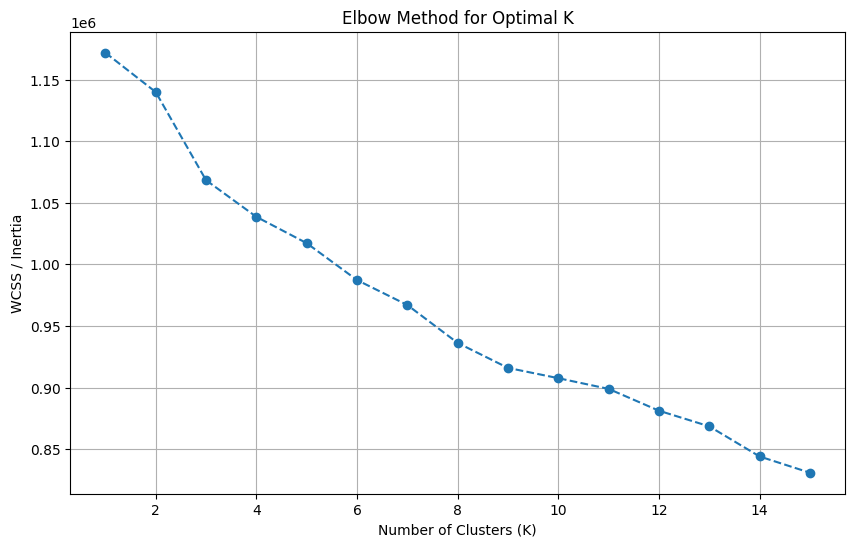

In [391]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define the range of K to test (e.g., from 1 to 15 clusters)
max_k = 15
wcss = [] # Within-Cluster Sum of Squares

for i in range(1, max_k + 1):
    # Use n_init='auto' for robustness and random_state for reproducibility
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()

--- Estatística de Hartigan para Escolha de K ---
     K  Estatística_Hartigan  Redução_Percentual
0    2                  0.07                6.70
1    3                  0.03                2.86
2    4                  0.02                2.10
3    5                  0.03                3.04
4    6                  0.02                2.10
5    7                  0.03                3.29
6    8                  0.02                2.21
7    9                  0.01                0.92
8   10                  0.01                0.97
9   11                  0.02                2.01
10  12                  0.01                1.46
11  13                  0.03                2.90
12  14                  0.02                1.59


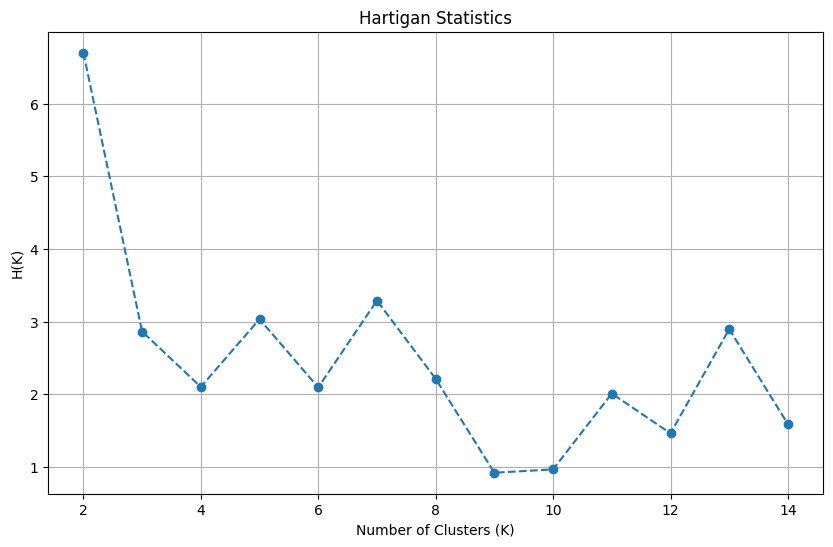

In [392]:
hartigan_stats = {}
max_k = len(wcss)

for k in range(2, max_k):
    wcss_k = wcss[k-1]
    wcss_k_plus_1 = wcss[k]

    hartigan = (wcss_k - wcss_k_plus_1) / wcss_k_plus_1
    
    hartigan_stats[k] = hartigan

hartigan_df = pd.DataFrame(
    list(hartigan_stats.items()), 
    columns=['K', 'Estatística_Hartigan']
)

hartigan_df['Redução_Percentual'] = hartigan_df['Estatística_Hartigan'] * 100

print("--- Estatística de Hartigan para Escolha de K ---")
print(hartigan_df.round(2))

plt.figure(figsize=(10, 6))
plt.plot(hartigan_df['K'], hartigan_df['Redução_Percentual'], marker='o', linestyle='--')
plt.title('Hartigan Statistics')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('H(K)')
plt.grid(True)
plt.show()

In [393]:
# Assuming optimal K is 5 based on the elbow plot
optimal_k = 9

# Initialize and train the final model
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
final_kmeans.fit(X_pca)

# Get the cluster labels for each bank
cluster_labels = final_kmeans.labels_

In [394]:
# 1. Add the cluster labels to the original DataFrame
df_filtrado['Cluster'] = cluster_labels
df_filtrado.columns = df_filtrado.columns.astype(str)

# 2. Profile the clusters by calculating the mean of the original (unscaled) features for each cluster
cluster_profiles = df_filtrado.groupby('Cluster')[X.columns].mean().sort_values(by='ativo realizavel - operacoes de credito', ascending=False)


print("\n--- Cluster Profiles (Centroid Means) ---")
print(cluster_profiles)

# 3. Save the results to a new CSV or update the SQLite database
df_filtrado[['cnpj', 'Cluster']].to_csv('bank_clusters.csv', index=False)
cluster_profiles.to_csv('cluster_profiles.csv', index=False)
# You can now use the 'Cluster' column as a categorical variable or for segmentation in your Ho and Saunders model.


--- Cluster Profiles (Centroid Means) ---
conta    ativo realizavel - ativo realizavel  \
Cluster                                        
4                                   0.466800   
2                                   0.463048   
5                                   0.569306   
1                                   0.342812   
7                                   0.259355   
8                                   0.225378   
0                                   0.792827   
3                                   0.275380   
6                                   0.618377   

conta    ativo realizavel - disponibilidades  ativo realizavel - caixa  \
Cluster                                                                  
4                                   0.015915                  0.000418   
2                                   0.005211                  0.003191   
5                                   0.155431                  0.016556   
1                                   0.005721              

In [395]:
'''result = df_filtrado[['ano', 'cnpj', 'nome', 'Cluster', '10000007', '16000001', '30000001', '30900008', '31000000', '40000008', '49000009', '60000002', '70000009', '71000008', '80000006', '81000005', '81700006', '90000003', '90900000', '91000002', '91100005']]

result = result.rename(columns={
    '10000007': 'CIRCULANTE E REALIZAVEL A LONGO PRAZO', 
    '16000001': 'OPERAÇÕES DE CRÉDITO', 
    '30000001': 'COMPENSACAO ATIVA',
    '30900008': 'Controle',
    '31000000': 'CLASSIFICACAO DA CARTEIRA DE CREDITOS',
    '40000008': 'CIRCULANTE E EXIGIVEL A LONGO PRAZO',
    '49000009': 'OUTRAS OBRIGACOES',
    '60000002': 'PATRIMONIO LIQUIDO',
    '70000009': 'CONTAS DE RESULTADO CREDORAS',
    '71000008': 'RECEITAS OPERACIONAIS',
    '80000006': 'CONTAS DE RESULTADO DEVEDORAS',
    '81000005': 'DESPESAS OPERACIONAIS',
    '81700006': 'Despesas Administrativas',
    '90000003': 'COMPENSACAO PASSIVA',
    '90900000': 'Controle',
    '91000002': 'CLASSIFICACAO DA CARTEIRA DE CREDITOS',
    '91100005': 'Operacoes De Creditos E Arrendamento Mercantil',
    })'''



"result = df_filtrado[['ano', 'cnpj', 'nome', 'Cluster', '10000007', '16000001', '30000001', '30900008', '31000000', '40000008', '49000009', '60000002', '70000009', '71000008', '80000006', '81000005', '81700006', '90000003', '90900000', '91000002', '91100005']]\n\nresult = result.rename(columns={\n    '10000007': 'CIRCULANTE E REALIZAVEL A LONGO PRAZO', \n    '16000001': 'OPERAÇÕES DE CRÉDITO', \n    '30000001': 'COMPENSACAO ATIVA',\n    '30900008': 'Controle',\n    '31000000': 'CLASSIFICACAO DA CARTEIRA DE CREDITOS',\n    '40000008': 'CIRCULANTE E EXIGIVEL A LONGO PRAZO',\n    '49000009': 'OUTRAS OBRIGACOES',\n    '60000002': 'PATRIMONIO LIQUIDO',\n    '70000009': 'CONTAS DE RESULTADO CREDORAS',\n    '71000008': 'RECEITAS OPERACIONAIS',\n    '80000006': 'CONTAS DE RESULTADO DEVEDORAS',\n    '81000005': 'DESPESAS OPERACIONAIS',\n    '81700006': 'Despesas Administrativas',\n    '90000003': 'COMPENSACAO PASSIVA',\n    '90900000': 'Controle',\n    '91000002': 'CLASSIFICACAO DA CARTEIRA DE

In [396]:
'''from sqlalchemy import create_engine

k_means_clusters = df_filtrado[['ano', 'cnpj', 'Cluster']]
engine = create_engine('sqlite:///dados/banking.db')

k_means_clusters.to_sql(
    'k_means_clusters',
    engine,
    if_exists='replace',
    index=False,
    chunksize=1000
)
'''

"from sqlalchemy import create_engine\n\nk_means_clusters = df_filtrado[['ano', 'cnpj', 'Cluster']]\nengine = create_engine('sqlite:///dados/banking.db')\n\nk_means_clusters.to_sql(\n    'k_means_clusters',\n    engine,\n    if_exists='replace',\n    index=False,\n    chunksize=1000\n)\n"